In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('resultados.csv')
df = df.drop(df.columns[0], axis=1)
display(df)

df2 = pd.read_csv('resultados2.csv')
df2 = df2.drop(df2.columns[0], axis=1)
display(df2)





,Linha,Coluna,Menor Soma Global,IndiceI,IndiceJ,alturaMenorXlarguraMenor,Submatrizes Percorridas,Tempo Total (s)
0,23,23,-17590,3,0,20x21,76176,0.012215
1,39,39,-42792,12,17,14x22,608400,0.235704
2,24,24,-14299,3,4,21x20,90000,0.014583
3,28,28,-13561,5,3,13x10,164836,0.035154
4,66,66,-344390,21,0,45x64,4888521,4.938220
...,...,...,...,...,...,...,...,...
795,38,38,-33909,20,2,17x36,549081,0.205216
796,35,35,-32771,3,8,32x15,396900,0.128000
797,47,47,-69670,0,11,28x20,1272384,0.694416
798,26,26,-19376,2,0,20x25,123201,0.023600


,Linha,Coluna,Menor Soma Global,IndiceI,IndiceJ,alturaMenorXlarguraMenor,Submatrizes Percorridas,Tempo Total (s),Unnamed: 9
0,23,23,-17590,3,0,20x21,76176,0.001195,NaN
1,39,39,-42792,12,17,14x22,608400,0.009059,NaN
2,24,24,-14299,3,4,21x20,90000,0.001365,NaN
3,28,28,-13561,5,3,13x10,164836,0.002471,NaN
4,66,66,-344390,21,0,45x64,4888521,0.050543,NaN
...,...,...,...,...,...,...,...,...,...
795,38,38,-33909,20,2,17x36,549081,0.005008,NaN
796,35,35,-32771,3,8,32x15,396900,0.003631,NaN
797,47,47,-69670,0,11,28x20,1272384,0.011463,NaN
798,26,26,-19376,2,0,20x25,123201,0.001170,NaN


In [ ]:

df_media = (
    df.groupby("Linha", as_index=False)["Tempo Total (s)"]
      .mean()
      .sort_values("Linha")
)

df_media2 = (
    df2.groupby("Linha", as_index=False)["Tempo Total (s)"]
      .mean()
      .sort_values("Linha")
)

tabela = pd.DataFrame({
    "Linha": df_media["Linha"],
    "Algoritmo 1 (s)": df_media["Tempo Total (s)"],
    "Algoritmo 2 (s)": df_media2["Tempo Total (s)"],
})

tabela["Submatrizes"] = (
    (tabela["Linha"] * (tabela["Linha"] + 1) / 2) ** 2
).astype(int)

tabela["Tamanho"] = (
    tabela["Linha"].astype(str) + " × " + tabela["Linha"].astype(str)
)

tabela = tabela[
    ["Tamanho", "Submatrizes", "Algoritmo 1 (s)", "Algoritmo 2 (s)"]
]

tabela_final = pd.concat(
    [tabela.head(10), tabela.tail(10)],
    ignore_index=True
)

latex = tabela_final.to_latex(
    index=False,
    float_format="%.6f",
    caption="Comparação entre os tempos médios dos algoritmos.",
    label="tab:comparacao",
)

with open("tabela_comparacao.tex", "w", encoding="utf-8") as f:
    f.write(latex)

display(tabela_final)


,Tamanho,Submatrizes,Algoritmo 1 (s),Algoritmo 2 (s)
0,1 × 1,1,0.000000e+00,9.000000e-07
1,2 × 2,9,8.000000e-07,1.000000e-06
2,3 × 3,36,8.000000e-07,1.600000e-06
3,4 × 4,100,1.200000e-06,2.900000e-06
4,5 × 5,225,8.000000e-06,4.500000e-06
5,6 × 6,441,4.800000e-06,6.100000e-06
6,7 × 7,784,1.840000e-05,1.010000e-05
7,8 × 8,1296,4.320000e-05,1.800000e-05
8,9 × 9,2025,7.680000e-05,2.690000e-05
9,10 × 10,3025,1.238000e-04,3.930000e-05


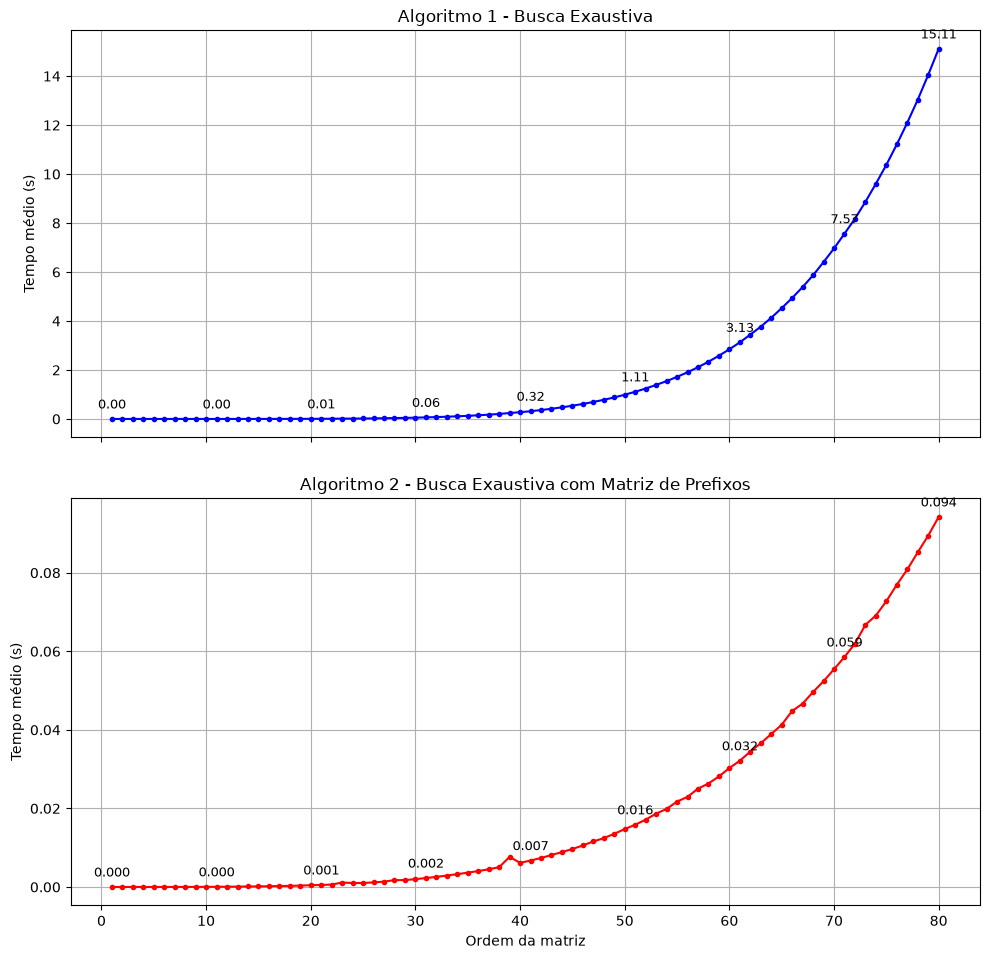

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_media = (
    df.groupby("Linha", as_index=False)["Tempo Total (s)"]
      .mean()
      .sort_values("Linha")
)

x = df_media["Linha"].values
y = df_media["Tempo Total (s)"].values

df_media2 = (
    df2.groupby("Linha", as_index=False)["Tempo Total (s)"]
      .mean()
      .sort_values("Linha")
)

x2 = df_media2["Linha"].values
y2 = df_media2["Tempo Total (s)"].values

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 10),
    sharex=True
)


ax1.plot(x, y, marker="o", ms=3, color="blue")

ax1.set_title("Algoritmo 1 - Busca Exaustiva")
ax1.set_ylabel("Tempo médio (s)")
ax1.grid(True)

offset = max(y) * 0.02

for i in range(0, len(x), 10):
    ax1.text(
        x[i],
        y[i] + offset,
        f"{y[i]:.2f}",
        fontsize=9,
        ha="center",
        va="bottom"
    )

last = len(x) - 1
if last % 10 != 0:
    ax1.text(
        x[last],
        y[last] + offset,
        f"{y[last]:.2f}",
        fontsize=9,
        ha="center",
        va="bottom"
    )

ax2.plot(x2, y2, marker="o", ms=3, color="red")
ax2.set_title("Algoritmo 2 - Busca Exaustiva com Matriz de Prefixos")
ax2.set_xlabel("Ordem da matriz")
ax2.set_ylabel("Tempo médio (s)")
ax2.grid(True)

offset2 = max(y2) * 0.02

for i in range(0, len(x2), 10):
    ax2.text(
        x2[i],
        y2[i] + offset2,
        f"{y2[i]:.3f}",
        fontsize=9,
        ha="center",
        va="bottom"
    )

last2 = len(x2) - 1
if last2 % 10 != 0:
    ax2.text(
        x2[last2],
        y2[last2] + offset2,
        f"{y2[last2]:.3f}",
        fontsize=9,
        ha="center",
        va="bottom"
    )

fig.tight_layout(rect=[0, 0, 1, 0.97], h_pad=2.5)

# Salvar
plt.savefig(
    "graficos/tempo_medio_execucao_SUBPLOT.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

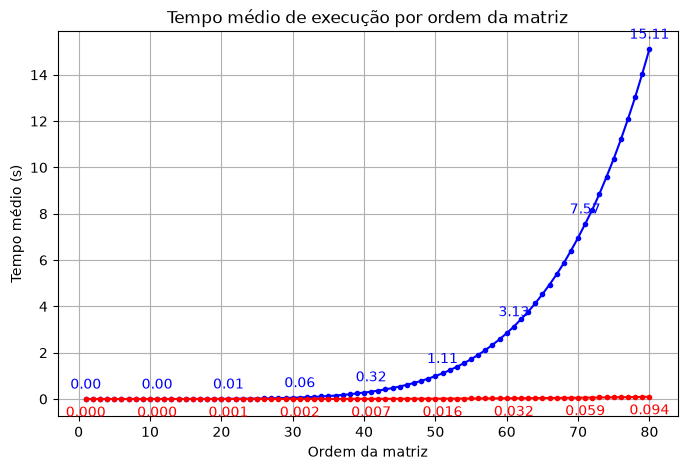

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_media = (
    df.groupby("Linha", as_index=False)["Tempo Total (s)"]
      .mean()
      .sort_values("Linha")
)


df_media2 = (
    df2.groupby("Linha", as_index=False)["Tempo Total (s)"]
      .mean()
      .sort_values("Linha")
)

x = df_media["Linha"].values
x2 = df_media2["Linha"].values
y = df_media["Tempo Total (s)"].values
y2 = df_media2["Tempo Total (s)"].values

plt.figure(figsize=(8, 5))
plt.plot(x, y, marker="o", ms=3, color="blue")
plt.plot(x2, y2, marker="o", ms=3, color="red")

plt.xlabel("Ordem da matriz")
plt.ylabel("Tempo médio (s)")
plt.title("Tempo médio de execução por ordem da matriz")
plt.grid(True)

offset = max(y) * 0.02  # deslocamento para cima
offset2 = max(y) * 0.02 # deslocamento para baixo

# Algoritmo 1 (texto acima)
for i in range(0, len(x), 10):
    plt.text(
        x[i],
        y[i] + offset,
        f"{y[i]:.2f}",
        fontsize=10,
        ha="center",
        va="bottom",
        color="blue"
    )

last = len(x) - 1
if last % 10 != 0:
    plt.text(
        x[last],
        y[last] + offset,
        f"{y[last]:.2f}",
        fontsize=10,
        ha="center",
        va="bottom",
        color="blue"
    )

# Algoritmo 2 (texto abaixo)
for i in range(0, len(x2), 10):
    plt.text(
        x2[i],
        y2[i] - offset2,
        f"{y2[i]:.3f}",
        fontsize=10,
        ha="center",
        va="top",
        color="red"
    )

last2 = len(x2) - 1
if last2 % 10 != 0:
    plt.text(
        x2[last2],
        y2[last2] - offset2,
        f"{y2[last2]:.3f}",
        fontsize=10,
        ha="center",
        va="top",
        color="red"
    )

plt.savefig("graficos/tempo_medio_execucao_alg1e2.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

,Linha,Submatrizes Percorridas
0,1,1.0
1,2,9.0
2,3,36.0
3,4,100.0
4,5,225.0
...,...,...
75,76,8561476.0
76,77,9018009.0
77,78,9492561.0
78,79,9985600.0


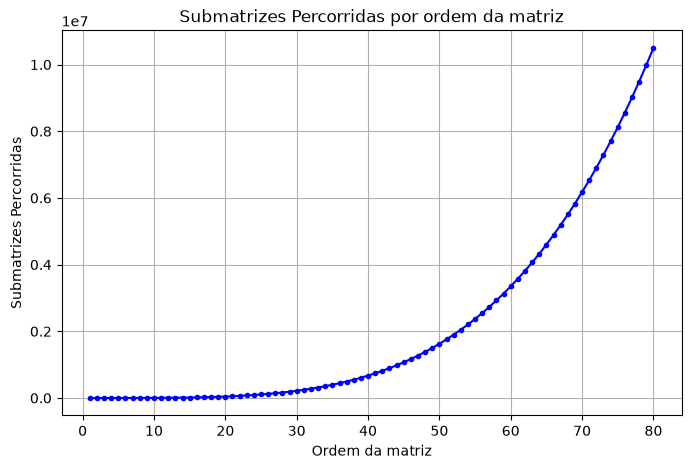

In [ ]:

df_submatrizes = (
    df.groupby("Linha", as_index=False)["Submatrizes Percorridas"]
      .mean()
      .sort_values("Linha")
)
display(df_submatrizes)

plt.figure(figsize=(8, 5))
plt.plot(df_submatrizes["Linha"], df_submatrizes["Submatrizes Percorridas"], marker="o", ms=3, color="blue")
plt.xlabel("Ordem da matriz")
plt.ylabel("Submatrizes Percorridas")
plt.title("Submatrizes Percorridas por ordem da matriz")
plt.grid(True)

plt.savefig("graficos/submatrizes_percorridas.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

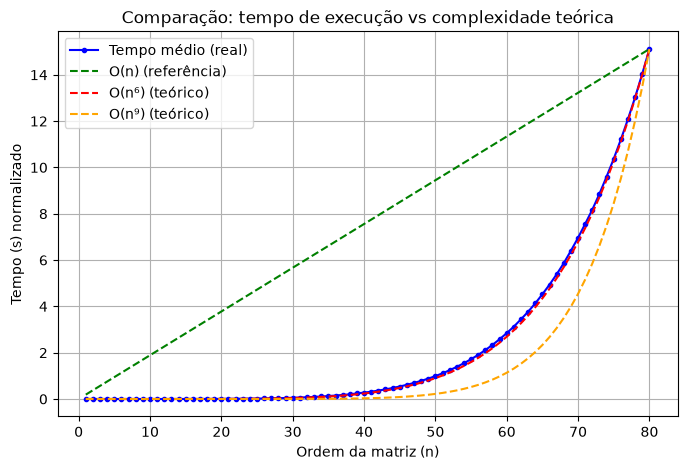

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_media = (
    df.groupby("Linha", as_index=False)["Tempo Total (s)"]
      .mean()
      .sort_values("Linha")
)

x = df_media["Linha"].values
y_real = df_media["Tempo Total (s)"].values

y_n6 = x ** 6
y_n9 = x ** 9
y_n = x

y_n6 = y_n6 / y_n6.max() * y_real.max()
y_n9 = y_n9 / y_n9.max() * y_real.max()
y_n = y_n / y_n.max() * y_real.max()

plt.figure(figsize=(8, 5))
plt.plot(x, y_real, marker="o", ms=3, label="Tempo médio (real)", color="blue")
plt.plot(x, y_n, linestyle="--", label="O(n) (referência)", color="green")
plt.plot(x, y_n6, linestyle="--", label="O(n⁶) (teórico)", color="red")
plt.plot(x, y_n9, linestyle="--", label="O(n⁹) (teórico)", color="orange")


plt.xlabel("Ordem da matriz (n)")
plt.ylabel("Tempo (s) normalizado")
plt.title("Comparação: tempo de execução vs complexidade teórica")
plt.grid(True)
plt.legend()

plt.savefig("graficos/tempo_vs_complexidade_alg1.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

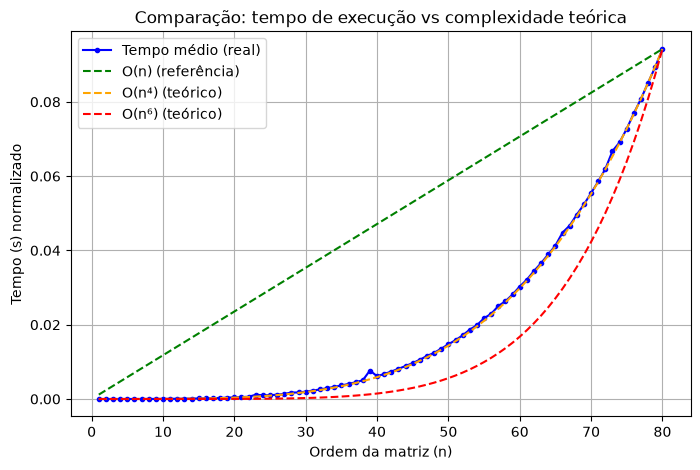

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_media2 = (
    df2.groupby("Linha", as_index=False)["Tempo Total (s)"]
      .mean()
      .sort_values("Linha")
)

x = df_media2["Linha"].values
y_real = df_media2["Tempo Total (s)"].values

y_n6 = x ** 6
y_n4 = x ** 4
y_n = x

# Normalização para mesma escala
y_n6 = y_n6 / y_n6.max() * y_real.max()
y_n4 = y_n4 / y_n4.max() * y_real.max()
y_n = y_n / y_n.max() * y_real.max()

# Plot
plt.figure(figsize=(8, 5))

plt.plot(x, y_real, marker="o", ms=3, label="Tempo médio (real)", color="blue")
plt.plot(x, y_n, linestyle="--", label="O(n) (referência)", color="green")
plt.plot(x, y_n4, linestyle="--", label="O(n⁴) (teórico)", color="orange")
plt.plot(x, y_n6, linestyle="--", label="O(n⁶) (teórico)", color="red")



plt.xlabel("Ordem da matriz (n)")
plt.ylabel("Tempo (s) normalizado")
plt.title("Comparação: tempo de execução vs complexidade teórica")
plt.grid(True)
plt.legend()

plt.savefig("graficos/tempo_vs_complexidade_alg2.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()